<a href="https://colab.research.google.com/github/nadhirahayani/Analisis-Deret-Waktu/blob/main/Hands_On_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [2]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1093) #diubah jadi 4 digit dari nim
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5*93
beta0 = 103
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


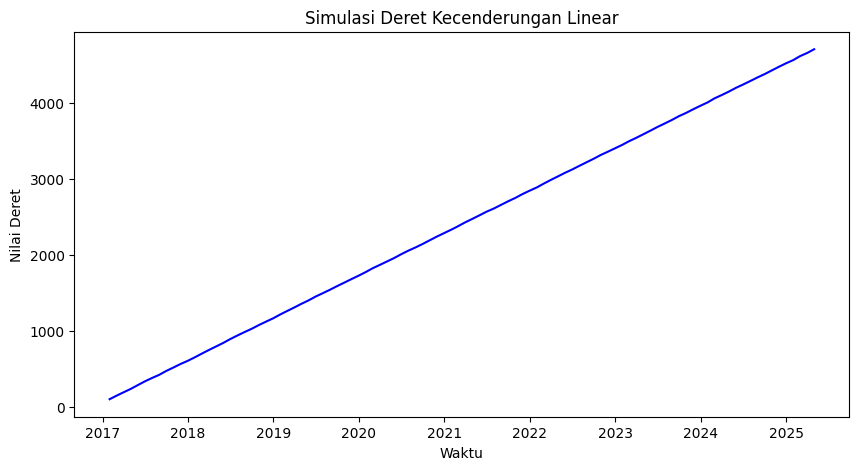

In [3]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan? Terdapat korelasi antara waktu dan nilai pengamatan dengan nilai korelasi sebesar 1. Hal ini menunjukkan adanya hubungan linear positif yang, yaitu seiring bertambahnya waktu, nilai pengamatan juga semakin meningkat. Hal tersebut menunjukkan deret memiliki tren atau kecenderungan positif.

In [4]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.211e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.56e-278
Time:                        12:21:44   Log-Likelihood:                -213.58
No. Observations:                 100   AIC:                             431.2
Df Residuals:                      98   BIC:                             436.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          102.5459      0.411    249.700   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**
Berdasarkan hasil di atas, diperoleh model regresi sebagai berikut:

$$ \hat{Y}=102.5459+46.5096(\text{Time_Numeric}) $$

Nilai parameter hasil pengepasan tersebut sangat mendekati nilai parameter asli yang digunakan dalam simulasi, yaitu $\beta_0=103$ dan $\beta_1=46.5$. Nilai estimasi intersep sebesar 102,5459 memiliki selisih yang kecil dari nilai asli, sedangkan estimasi slope sebesar 46,5096 hampir sama dengan nilai asli 93,5. Hal ini menunjukkan bahwa model regresi yang dipaskan mampu mengestimasi parameter asli dengan sangat baik.


**Apakah model regresi yang dipaskan sudah bagus?**
Ya, model regresi yang dipaskan sudah bagus. Dapat dilihat dari nilai $R^2$ yaitu sebesar $1$ yang artinya sekitar 100% variasi nilai pengamatan dapat dijelaskan oleh variabel waktu. Selain itu berdasarkan uji F,  $p-value$ yang dihasilkan juga $0.05$ yang artinya model secara keseluruhan signifikan dan koefisien $Time Numeric$ juga berpengaruh signifikan.

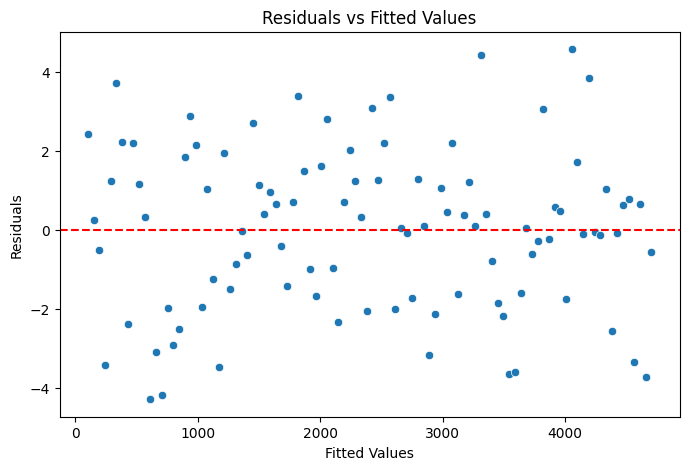

In [8]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**
Berdasarkan plot tersebut, dapat dilihat bahwa residual menyebar secara acak di sekitar garis nol dan tidak menunjukkan pola tertentu. Hal ini menandakan bahwa ragam dari sisaan relatif konstan atau homoskedastisitas sehingga model regresi dapat dikatakan cukup baik.

In [9]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4035


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**
Berdasarkan uji Breusch Pagan, didapatkan p-value sebesar 0.4035 yang artinya <0.05. Sehingga tak tolak H0, tidak cukup bukti untuk menyatakan adanya heteroskedastisitas. Yang artinya ragam dari residual konstan (homoskedastisitas).

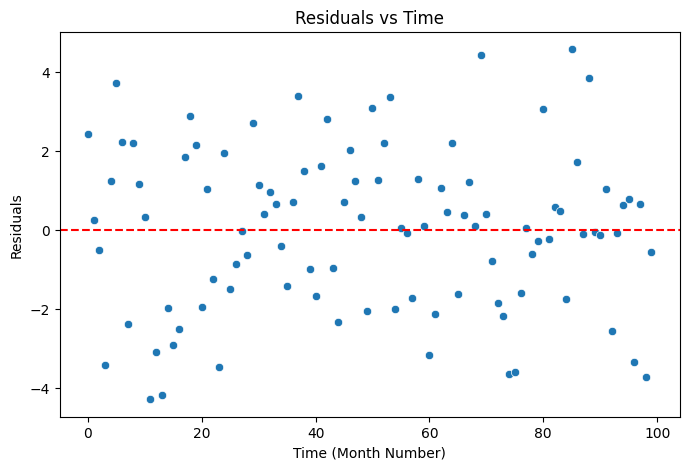

In [10]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

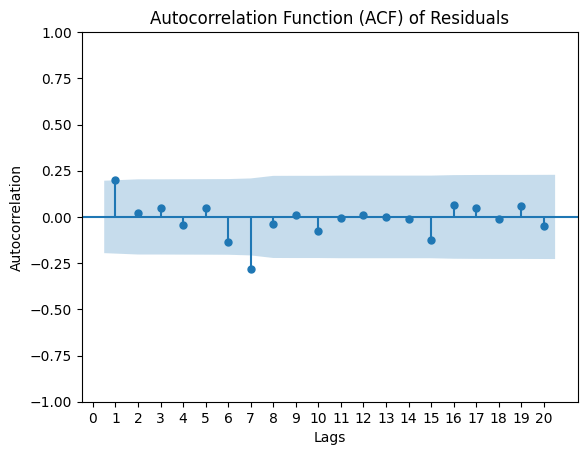

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?** Berdasarkan plot ACF di atas, pada lag 1 dan lag 7 nilai autokorelasi berada di luar selang kepercayaan, sehingga terdapat indikasi autokorelasi pada lag ke 1 dan ke 7.

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    4.005521   0.045351
2    4.046939   0.132196
3    4.281780   0.232601
4    4.503072   0.342183
5    4.727169   0.450076
6    6.796511   0.340077
7   15.351502   0.031749
8   15.527138   0.049671
9   15.544349   0.077028
10  16.220217   0.093500
11  16.227201   0.132904
12  16.239369   0.180517
13  16.240505   0.236386
14  16.253331   0.298150
15  18.144283   0.255156
16  18.652135   0.287114
17  18.915322   0.333414
18  18.929144   0.396199
19  19.335562   0.435507


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?** Pada lag 1, 7, dan 8, p-value bernilai kurang dari 0.05 sehingga terdapat bukti adanya residual sampai lag tersebut. Sehingga residual belum sepenuhnya bersifat white noise.

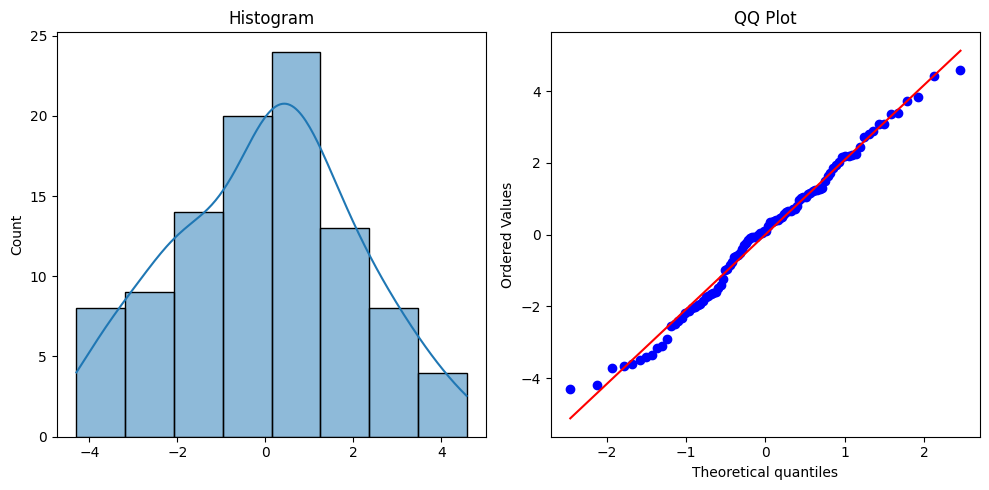

In [13]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?** Berdasarkan histogram dan QQ plot di atas, residual ada umumnya berdistribusi normal. Hal ini ditunjukkan pada histogram yang bentuknya menyerupai distribusi normal dan pada QQ plot yang sebagian besar titiknya berada pada garis diagonal. Sehingga, residual dianggap sudah mengikuti distribusi normal.

In [14]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9866279221983242, p-value = 0.41309445225255365


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?** Berdasarkan uji Shapiro Wilk didapatkan p-value sebesar 0.4131 yang artinya lebih besar dari 0.05. Sehingga gagal tolak H0, akibatnya tidak cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Hasil ini sejalan dengan kesimpulan yang diperoleh berdasarkan plot histogram dan QQ plot di atas.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [15]:
# Menentukan parameter simulasi
np.random.seed(1093)
n_periods = 120
beta_0, beta_1, beta_2= 143, 0.5*93, 0.02*93
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

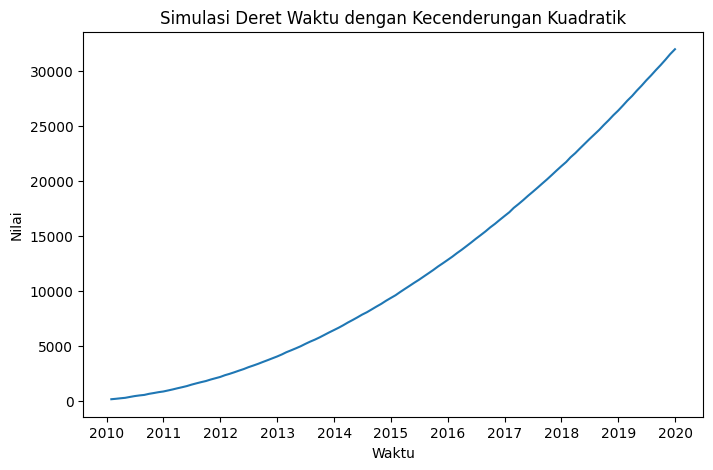

In [16]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?** Berdasarkan plot di atas, nilai pengamatan deret waktu memiliki kecenderungan positif berbentuk kuadratik. Hal ini ditandai dengan nilai pengamatan yang terus meningkat dan laju peningkatan yang semakin besar seiring berjalanny waktu. Berbeda dengan kecenderungan linear yang hanya membentuk garis lurus dengan laju perubahan relatif konstan, kecenderungan kuadratik membentuk kurva yang semakin curam sehingga menunjukkan bahwa laju perubahan nilai semakin meningkat seiring berjalannya waktu.

In [19]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.814e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:29:24   Log-Likelihood:                -452.01
No. Observations:                 120   AIC:                             910.0
Df Residuals:                     117   BIC:                             918.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        139.3793      2.854     48.833      0.0

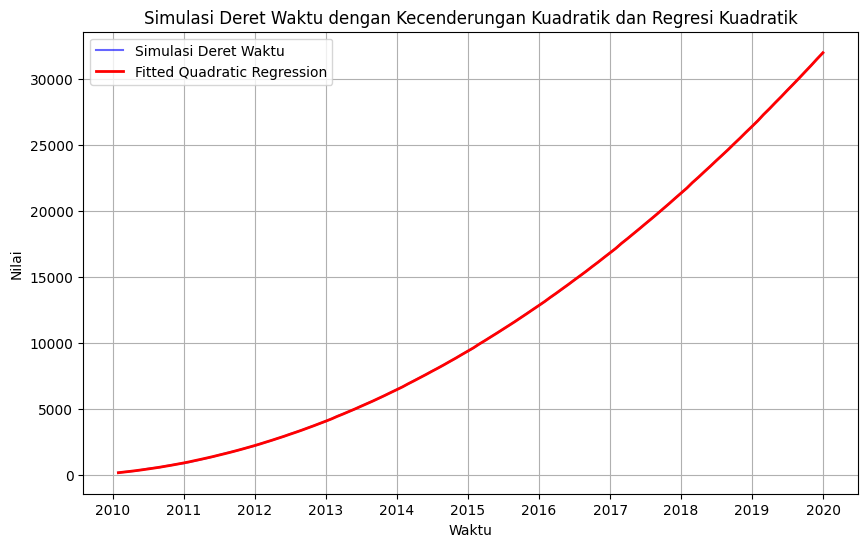

In [18]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**
Berdasarkan hasil regresi kuadratik di atas didapatkan persamaan model
$\hat{Y}=139.3793+93.6154X+93.0195X^2$ Berdasarkan uji Jarque-Bera diperoleh p-value sebesar 0,285 > 0,05, sehingga tak tolak H0. Artinya, tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Jadi, residual dapat dianggap berdistribusi normal.

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!** Dapat dilihat bahwa model memiliki nilai $R^2=1$, yang berarti 100% variasi nilai pengamatan dapat dijelaskan oleh model. Selain itu, dari plot terlihat bahwa hasil regresi kuadratik mengikuti pola deret dengan sangat baik. Jadi, model regresi kuadratik yang dipaskan sudah tepat untuk menggambarkan deret tersebut.

In [17]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [20]:
# Menentukan parameter simulasi
np.random.seed(1093)
n_periods = 120
beta0, beta1, beta2=143,-25*93, -2*93
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


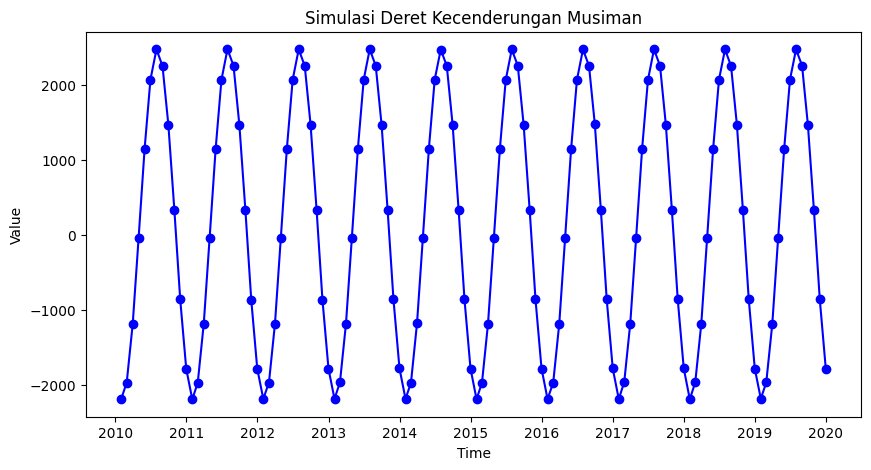

In [21]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?** Dapat dilihat pada plot di atas, deret memiliki pola musiman dengan periode 12. Nilai pengamatan mengalami pola naik dan turun yang berulang setiap 12 periode, dengan puncak nilai pengamatan tertinggi terdapat pada pertengahan tahun, dapat dilihat pula pola tersebut konsisten dari tahun 2010 hingga 2020. Oleh karena itu deret tersebut dapat dikatakan memiliki musiman dengan periode 12.

In [22]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [23]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [24]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [25]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.971e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.60e-310
Time:                        12:53:36   Log-Likelihood:                -250.90
No. Observations:                 120   AIC:                             525.8
Df Residuals:                     108   BIC:                             559.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -2182.4363      0.653  -3344.067      0.0

**Bagaimana interpretasi dari hasil tersebut?** Hasil regresi menunjukkan bahwa model mampu menangkap pola musiman dengan periode 12 dengan sangat baik. Hal ini dapat dilihat dari nilai $R^2=1$ yang artinya 100% variasi nilai pengamatan dapat dijelaskan oleh pola musiman bulan. Selain itu model secara keseluruhan signifikan dan seluruh koefisien bulan juga signifikan, dapat dilihat dari p-value yang bernilai kurang dari 0.05. Pola nilai menunjukkan kenaikan dari awal tahun hingga mencapai nilai tertinggi pada bulan Juli, kemudian menurun hingga akhir tahun. Dengan demikian, hasil regresi sesuai dengan pola musiman yang terlihat pada deret.

In [27]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

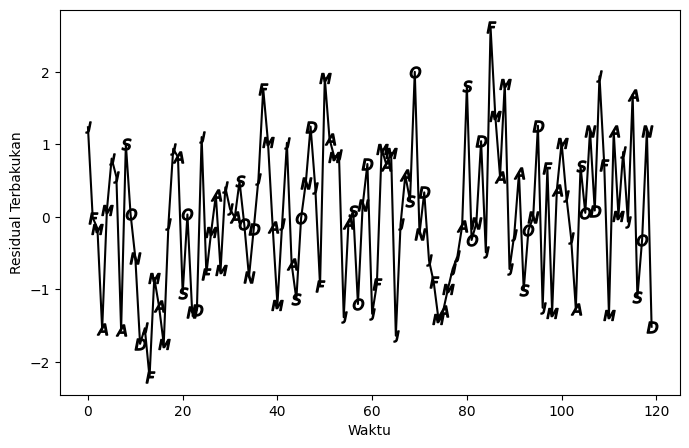

In [28]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


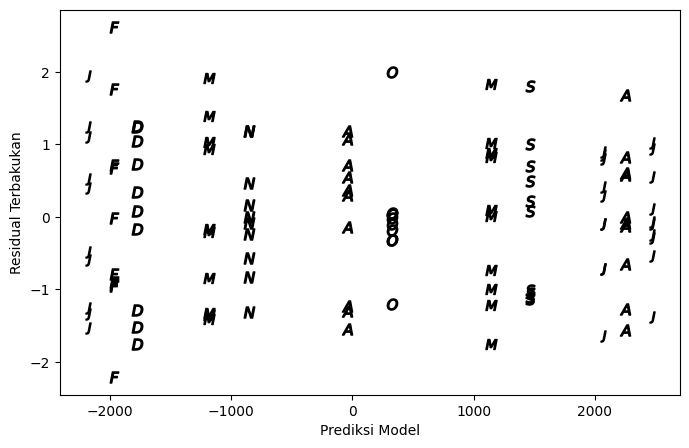

In [29]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

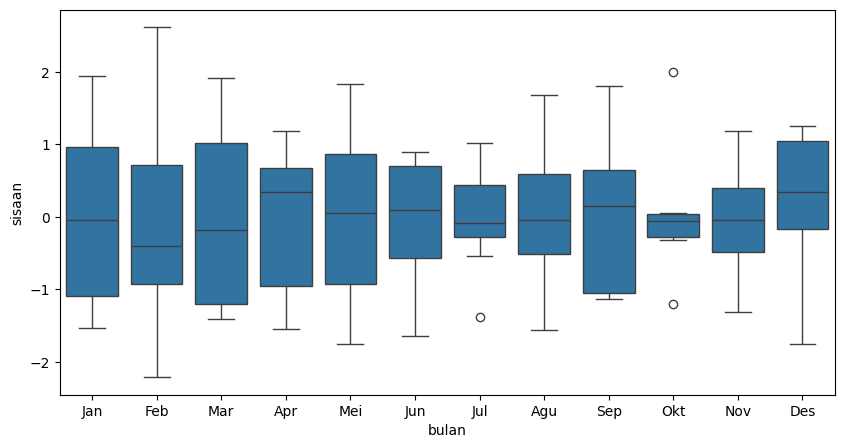

In [30]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap tiga plot di atas?** Berdasarkan plot pertama yaitu residual terhadap waktu, dapat dilihat bahwa residual menyebar di sekitar garis nol secara acak dan tidak membentuk pola tertentu. Begitu pula pada plot kedua yaitu plot residual dengan prediksi model, residual menyebar secara acak pada berbagai nilai prediksi serta tidak membentuk pola tertentu. Pada plot ketiga yaitu residual berdasarkaan bulan, terlihat bahwa median residual pada sebagian besar bulan berada di sekitar nol, meskipun terdapat perbedaan penyebaran antar bulannya. Terdapat beberapa outlier juga pada bulan Juli dan Oktober. Secara keseluruhan, berdasarkan ketiga plot di atas, residual tersebar secara acak di sekitar nilai nol dan tidak meunjukkan pola tertentu.

In [31]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# =========================
# 1. Membuat data simulasi
# =========================

np.random.seed(1093)

n_periods = 120
beta0, beta1, beta2 = 143, -25*93, -2*93
freq = 1/12

time = np.arange(n_periods)

# Komponen musiman
seasonal_component = (
    beta0
    + beta1 * np.cos(2*np.pi*time*freq)
    + beta2 * np.sin(2*np.pi*time*freq)
)

# Noise
noise = np.random.normal(0, 2, n_periods)

# Data
data = seasonal_component + noise

# Index waktu
dates = pd.date_range(
    start='2010-01-01',
    periods=n_periods,
    freq='ME'
)

# DataFrame
df_seasonal = pd.DataFrame({
    'Date': dates,
    'Value': data
})


# =========================
# 2. Membuat variabel dummy bulan
# =========================

df_seasonal['bulan'] = df_seasonal['Date'].dt.month

# Dummy bulan
X = pd.get_dummies(
    df_seasonal['bulan'],
    prefix='bulan',
    drop_first=False
).astype(float)

y = df_seasonal['Value']

# Model OLS
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())


# =========================
# 3. Mengambil residual
# =========================

residuals = model.resid
fitted = model.fittedvalues


# =========================
# 4. Uji normalitas
# =========================

# Jarque-Bera
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

print("\n=== Jarque-Bera Test ===")
print("Statistik JB :", jb_stat)
print("p-value      :", jb_pvalue)

# Shapiro-Wilk
sw_stat, sw_pvalue = shapiro(residuals)

print("\n=== Shapiro-Wilk Test ===")
print("Statistik W  :", sw_stat)
print("p-value      :", sw_pvalue)


# =========================
# 5. Uji homoskedastisitas
# =========================

# Breusch-Pagan
bp_test = het_breuschpagan(residuals, X)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("\n=== Breusch-Pagan Test ===")
print("Statistik BP :", bp_stat)
print("p-value      :", bp_pvalue)


# =========================
# 6. Uji autokorelasi
# =========================

# Durbin-Watson
dw_stat = durbin_watson(residuals)

print("\n=== Durbin-Watson ===")
print("Statistik DW :", dw_stat)


# Ljung-Box sampai lag 12
ljung_box = acorr_ljungbox(
    residuals,
    lags=12,
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_box)

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.971e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.60e-310
Time:                        13:31:10   Log-Likelihood:                -250.90
No. Observations:                 120   AIC:                             525.8
Df Residuals:                     108   BIC:                             559.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.1370      0.174    759.820      0.0

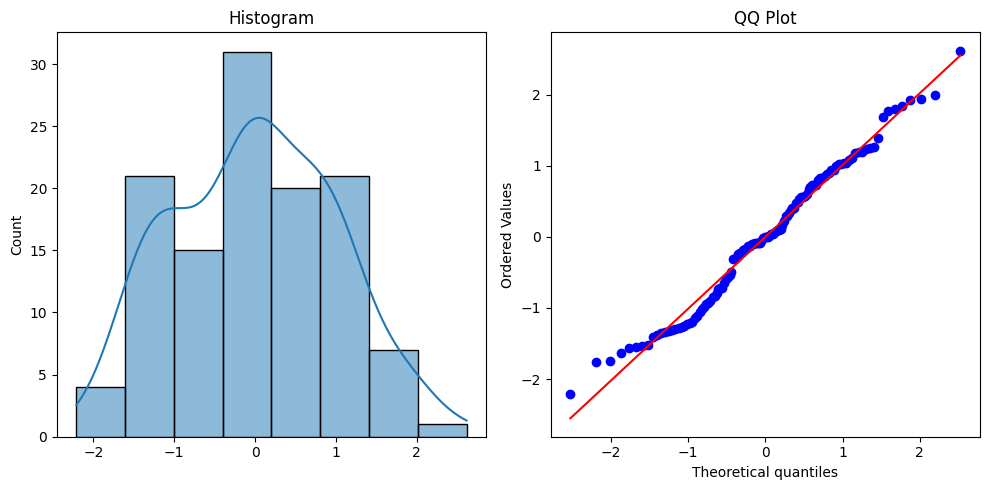

In [27]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**
Berdasarkan plot histogram, dapat dilihat bahwa residual yang dihasilkan dari model memiliki bentuk yang menyerupai distribusi normal. Berdasarkan QQ plot, sebagian besar titik residual juga berada di sekitar garis diagonal, sehingga residual dapat dikatakan mendekati distribusi normal, walaupun masih terdapat beberapa titik yang menyimpang dari garis tersebut.

**Hitunglah statistik uji untuk mengecek asumsi model**
Berdasarkan hasil uji asumsi residual yang dihasilkan dari model sudah memenuhi asumsi normalitas, hal ini ditunjukkan dari uji Jarque Bera yang menghasilkan p-value lebih besar dari 0.05. Namun, berdasarkan uji Breusch-Pagan diperoleh p-value sebesar 0,012 yang lebih kecil dari 0,05, sehingga terdapat heteroskedastisitas pada residual. Sehingga, model belum memenuhi seluruh asumsi regresi karena asumsi homoskedastisitas tidak terpenuhi.  

In [32]:
print("\n===== HASIL UJI ASUMSI =====")

print(f"Jarque-Bera   : statistik = {jb_stat:.4f}, p-value = {jb_pvalue:.4f}")
print(f"Shapiro-Wilk  : statistik = {sw_stat:.4f}, p-value = {sw_pvalue:.4f}")
print(f"Breusch-Pagan : statistik = {bp_stat:.4f}, p-value = {bp_pvalue:.4f}")
print(f"Durbin-Watson : statistik = {dw_stat:.4f}")

print("\nLjung-Box:")
print(ljung_box)


===== HASIL UJI ASUMSI =====
Jarque-Bera   : statistik = 2.2221, p-value = 0.3292
Shapiro-Wilk  : statistik = 0.9828, p-value = 0.1283
Breusch-Pagan : statistik = 14.4284, p-value = 0.2742
Durbin-Watson : statistik = 1.7757

Ljung-Box:
     lb_stat  lb_pvalue
1   1.139134   0.285835
2   1.793288   0.407936
3   2.873420   0.411556
4   3.086790   0.543408
5   4.774019   0.444077
6   4.798341   0.569925
7   5.592023   0.588109
8   6.783730   0.560136
9   7.889069   0.545363
10  8.797430   0.551430
11  8.827647   0.637798
12  9.143734   0.690607


In [28]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [29]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [30]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.636e+04
Date:                Wed, 02 Sep 2026   Prob (F-statistic):          1.50e-168
Time:                        02:19:53   Log-Likelihood:                -250.90
No. Observations:                 120   AIC:                             525.8
Df Residuals:                     108   BIC:                             559.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        210.5637      0.653    322.639      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**
Model dengan intersep menggunakan Januari sebagai bulan acuan. Nilai intersep sebesar 210,5637 menunjukkan nilai prediksi pada bulan Januari. Sementara itu, koefisien pada bulan lainnya menunjukkan selisih nilai bulan tersebut terhadap Januari. Misalkan, koefisien Februari sebesar 36,6442 berarti nilai Februari sekitar 36,6442 lebih tinggi dibandingkan Januari.

**Apakah model dengan intersep sudah memenuhi asumsi regresi?**
Dari uji Jarque-Bera, diperoleh p-value sebesar 0,329 yang lebih besar dari 0,05 sehingga residual dapat dianggap berdistribusi normal. Nilai Durbin-Watson sebesar 1,776 juga cukup dekat dengan 2, sehingga tidak terlihat adanya autokorelasi yang kuat pada lag pertama.

In [31]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [33]:
# Parameter
np.random.seed(1093)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*93, 10*93 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


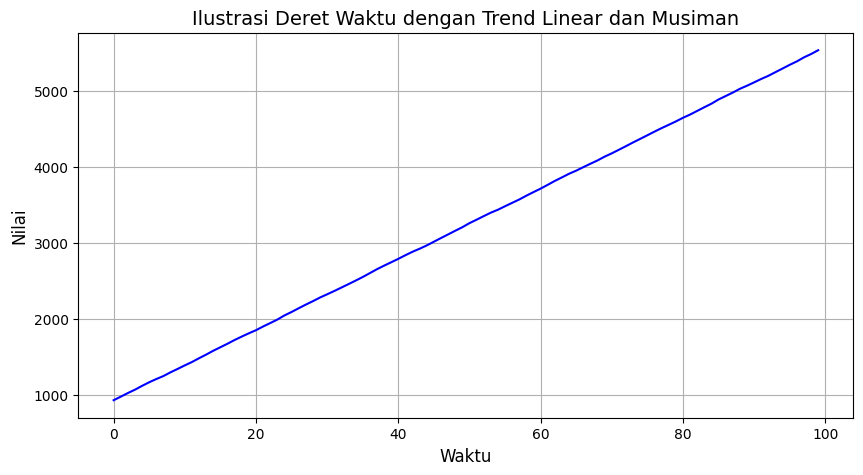

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [35]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [36]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [37]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.604e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.88e-242
Time:                        13:53:24   Log-Likelihood:                -206.29
No. Observations:                 100   AIC:                             438.6
Df Residuals:                      87   BIC:                             472.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      928.6438      0.761   1220.748      0.0

**Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?** Berdasarkan hasil regresi, koefisien dari masing masing bulan menunjukkan nilai dasar pengamatan untuk setiap bulan. Nilai koefisien terbesar terdapat pada bulan Mei yaitu sebesar 934,2270, sedangkan yang terkecil pada bulan September yaitu sebesar 925,1064. Dapat dilihat pula koefisien period sebesar 46,5104 menunjukkan bahwa setiap bertambah satu periode, nilai pengamatan diperkirakan meningkat sebesar 46,5104. Jadi, dapat dikatakan bahwa data memiliki tren positif, yaitu nilai pengamatan cenderung meningkat seiring bertambahnya waktu.

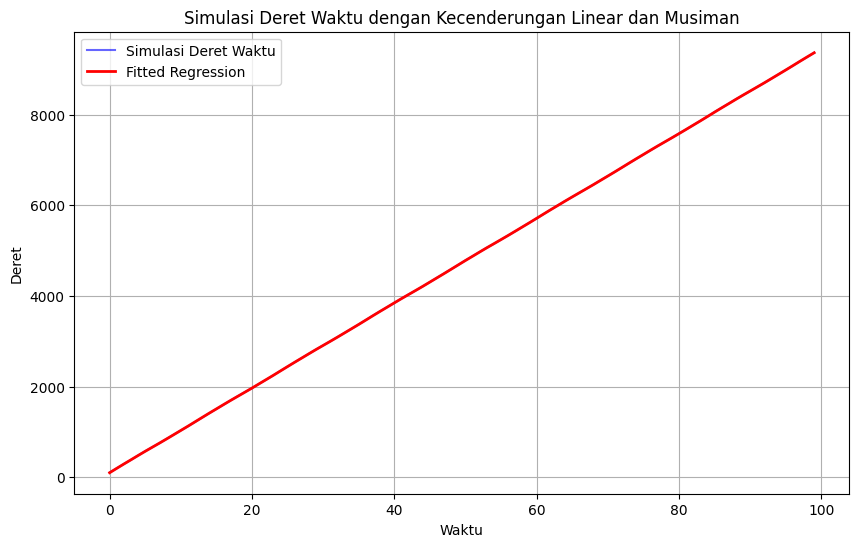

In [37]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# uji asumsi model
# =========================
# 1. UJI NORMALITAS
# =========================

# Shapiro-Wilk
residual = model.resid
shapiro_stat, shapiro_p = shapiro(residual)

print("=== Shapiro-Wilk ===")
print("Statistic :", shapiro_stat)
print("p-value   :", shapiro_p)


# Jarque-Bera
jb_stat, jb_p, skew, kurtosis = jarque_bera(residual)

print("\n=== Jarque-Bera ===")
print("Statistic :", jb_stat)
print("p-value   :", jb_p)


# =========================
# 2. UJI HOMOSKEDASTISITAS
# =========================

bp_stat, bp_p, f_stat, f_p = het_breuschpagan(residual, X)

print("\n=== Breusch-Pagan ===")
print("LM Statistic :", bp_stat)
print("p-value      :", bp_p)


# =========================
# 3. UJI AUTOKORELASI
# =========================

# Durbin-Watson
dw = durbin_watson(residual)

print("\n=== Durbin-Watson ===")
print("DW :", dw)


# Ljung-Box
lb = acorr_ljungbox(
    residual,
    lags=[1, 6, 12],
    return_df=True
)

print("\n=== Ljung-Box ===")
print(lb)

=== Shapiro-Wilk ===
Statistic : 0.9827552686867194
p-value   : 0.12825249807033096

=== Jarque-Bera ===
Statistic : 2.222085870994887
p-value   : 0.32921543150691235

=== Breusch-Pagan ===
LM Statistic : 14.428384773538374
p-value      : 0.2741926518155214

=== Durbin-Watson ===
DW : 1.7756868993336439

=== Ljung-Box ===
     lb_stat  lb_pvalue
1   1.139134   0.285835
6   4.798341   0.569925
12  9.143734   0.690607


**Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!** Dilakukan beberapa uji untuk mengecek apakah model tersebut sudah memenuhi asumsi yang ada. Berdasarkan uji Shapiro-Wilk dan Jarque-Bera, diperoleh p-value yang lebih besar dari 0,05 sehingga H₀ tidak ditolak dan residual dianggap berdistribusi normal. Selain itu, dilakukan uji Breusch-Pagan dan diperoleh p-value yang lebih besar dari 0,05, sehingga varians residual dapat dianggap konstan atau bersifat homoskedastis. Nilai Durbin-Watson sebesar 1,7757 yang cukup dekat dengan 2 menunjukkan tidak adanya autokorelasi yang kuat pada lag pertama. Hasil uji Ljung-Box juga menunjukkan p-value pada lag 1, 6, dan 12 lebih besar dari 0,05, sehingga tidak terdapat autokorelasi yang signifikan pada residual. Dengan demikian, dapat disimpulkan bahwa model yang digunakan sudah memenuhi asumsi dasar regresi.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [41]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

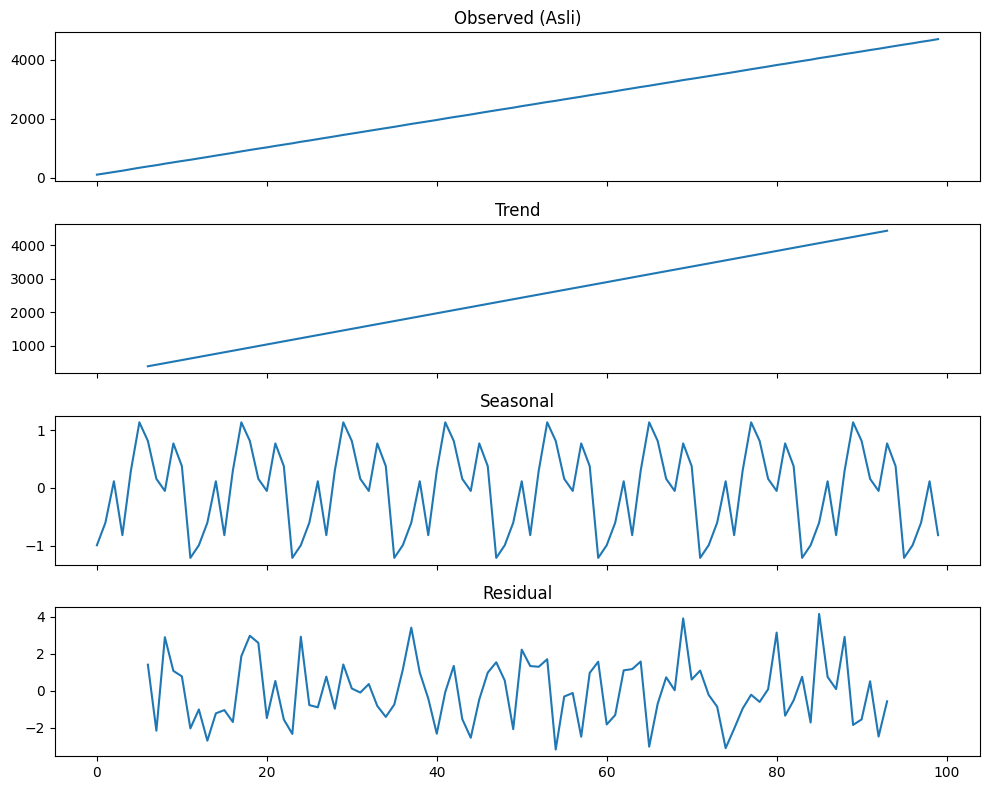

In [42]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?** Berdasarkan hasil dekomposisi, pada komponen tren terlihat adanya pola yang meningkat secara linear seiring bertambahnya waktu. Pola ini menunjukkan adanya tren linear positif. Pada komponen seasonal terlihat pola yang berulang secara teratur, sehingga menunjukkan adanya pola musiman pada deret. Sementara itu, komponen residual berfluktuasi di sekitar nol dan tidak menunjukkan adanya pola tertentu. Secara keseluruhan, deret asli terbentuk dari tren yang meningkat, pola musiman yang berulang, serta variasi acak pada residual.

In [44]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

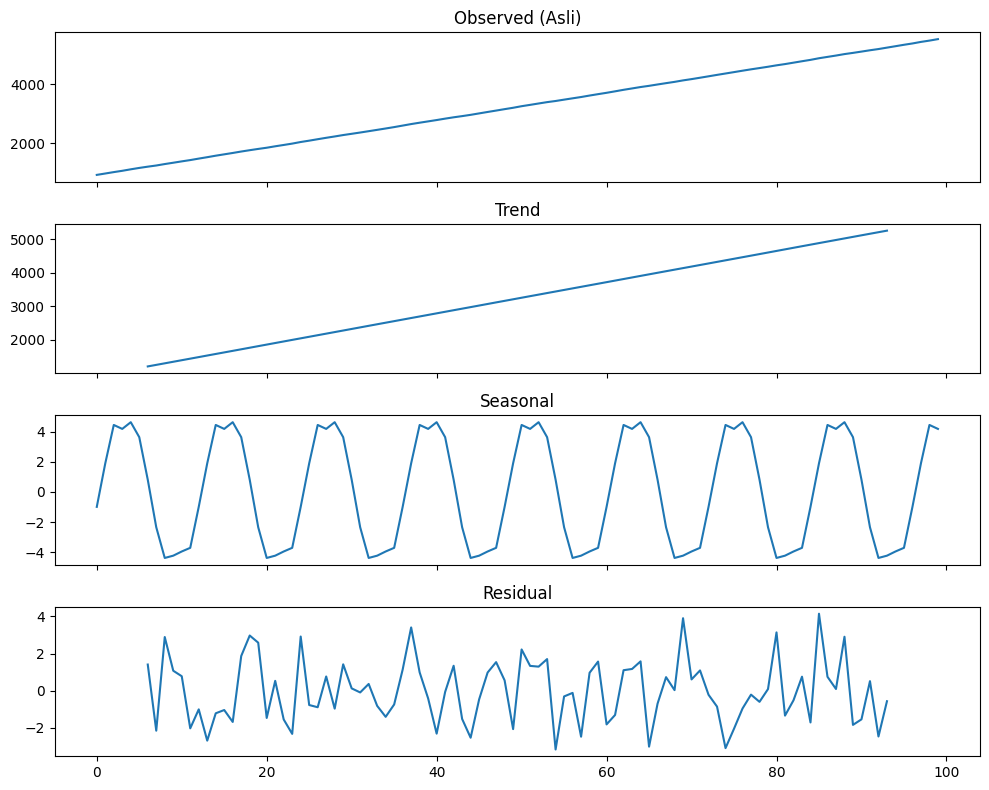

In [45]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?** Berdasarkan hasil dekomposisi, pada komponen tren terlihat adanya pola yang meningkat secara linear seiring bertambahnya waktu, sehingga menunjukkan adanya tren linear positif. Pada komponen seasonal, terlihat pola naik dan turun yang berulang secara teratur, sehingga menunjukkan adanya pola musiman pada deret. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu, sehingga dapat dianggap sebagai variasi acak yang tidak dijelaskan oleh tren dan seasonal. Secara keseluruhan, deret asli terdiri dari tren yang meningkat, pola musiman yang berulang, dan variasi acak pada residual.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [46]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1093)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*93, 10*93 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

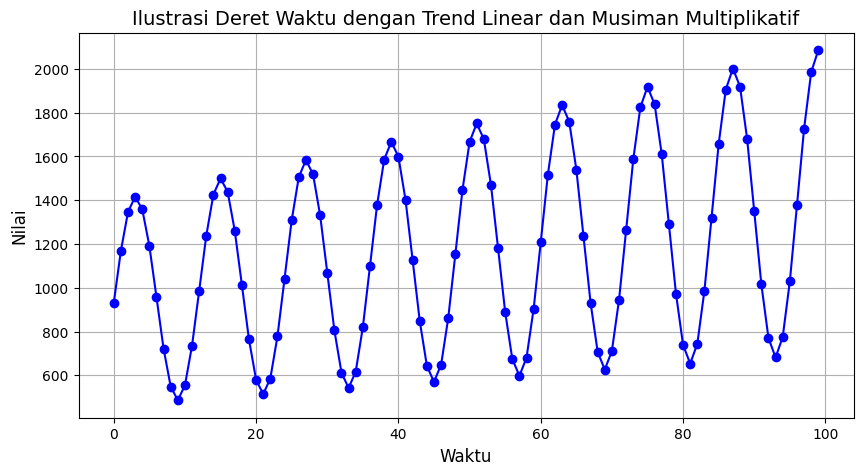

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [48]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

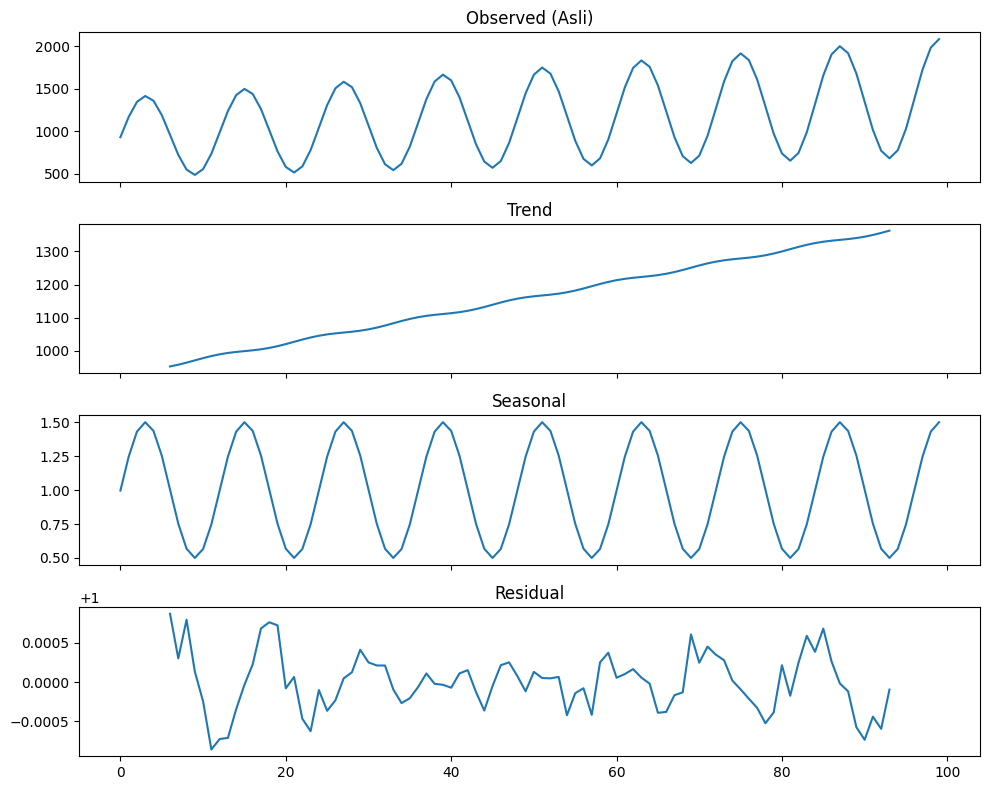

In [49]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?** Berdasarkan hasil dekomposisi, pada komponen tren terlihat adanya pola yang meningkat secara perlahan seiring bertambahnya waktu, sehingga menunjukkan adanya tren positif. Pada komponen seasonal, terlihat pola naik dan turun yang berulang secara teratur dengan bentuk yang hampir sama, sehingga menunjukkan adanya pola musiman yang kuat. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dengan nilai yang sangat kecil dan tidak menunjukkan pola tertentu. Secara keseluruhan, deret asli dipengaruhi oleh tren yang meningkat dan pola musiman yang kuat, sedangkan sisanya berupa variasi acak pada residual.

In [50]:
# Parameter
np.random.seed(1093)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

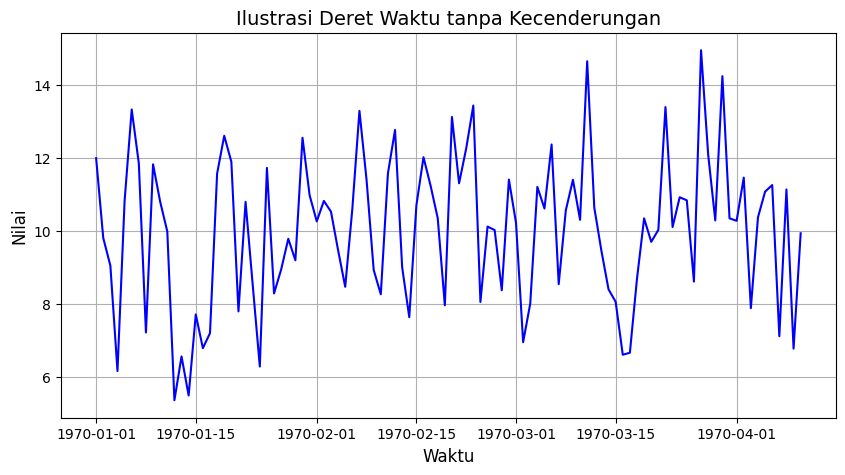

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

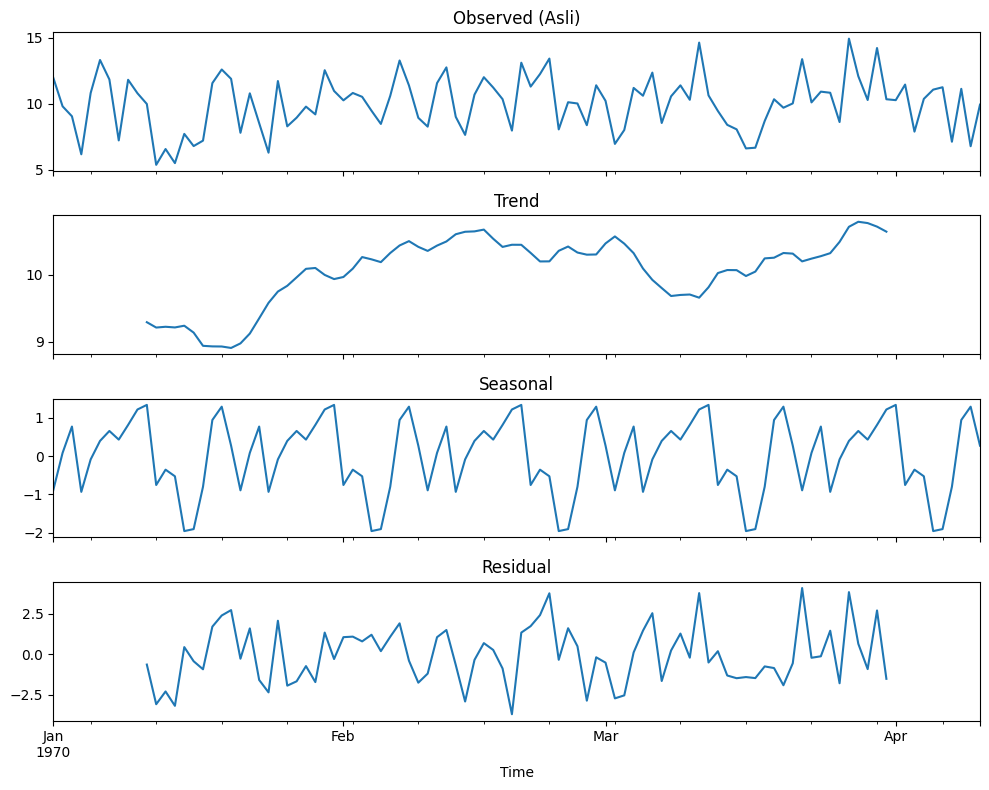

In [52]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?** Berdasarkan hasil plot dekomposisi, pada komponen tren terlihat adanya perubahan nilai dari waktu ke waktu. Nilai tren awalnya menurun, kemudian meningkat hingga sekitar pertengahan periode, sempat menurun, dan kembali meningkat menjelang akhir periode. Pada komponen seasonal, terlihat adanya pola naik dan turun yang berulang secara teratur, sehingga menunjukkan adanya pola musiman pada deret. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu. Secara keseluruhan, deret asli dipengaruhi oleh perubahan tren, pola musiman yang berulang, serta variasi acak pada residual.